In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("SalesAnalysis").getOrCreate()

from pyspark.sql.functions import *

In [2]:
sales_data = [
    (1001, "Hyderabad", "Electronics", "Laptop", 2, 65000, "Completed"),
    (1002, "Bangalore", "Electronics", "Mobile", 3, 25000, "Completed"),
    (1003, "Mumbai", "Furniture", "Chair", 5, 3500, "Pending"),
    (1004, "Delhi", "Furniture", "Table", 2, 12000, "Completed"),
    (1005, "Chennai", "Fashion", "Shoes", 4, 2500, "Completed"),
    (1006, "Pune", "Fashion", "Watch", 1, 8000, "Cancelled"),
    (1007, "Hyderabad", "Electronics", "TV", 1, 45000, "Completed"),
    (1008, "Mumbai", "Electronics", "Laptop", 2, 65000, "Completed"),
    (1009, "Delhi", "Furniture", "Chair", 3, 3500, "Pending"),
    (1010, "Bangalore", "Fashion", "Shoes", 5, 2500, "Completed"),
    (1011, "Chennai", "Electronics", "Mobile", 4, 25000, "Completed"),
    (1012, "Hyderabad", "Fashion", "Watch", 2, 8000, "Completed")
]

columns = ["order_id", "city", "category", "product", "quantity", "price", "status"]

df = spark.createDataFrame(sales_data, columns)

df = df.withColumn("revenue", col("quantity") * col("price"))

display(df)


DataFrame[order_id: bigint, city: string, category: string, product: string, quantity: bigint, price: bigint, status: string, revenue: bigint]

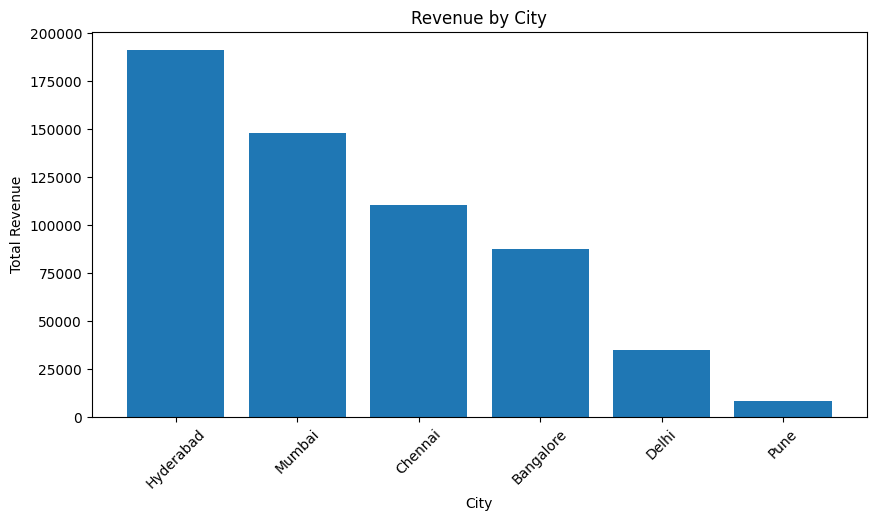

In [3]:

import matplotlib.pyplot as plt

city_revenue_df = df.groupBy("city").agg(
    sum("revenue").alias("total_revenue")
).orderBy(col("total_revenue").desc())

city_pd = city_revenue_df.toPandas()

plt.figure(figsize=(10, 5))
plt.bar(city_pd["city"], city_pd["total_revenue"])
plt.xlabel("City")
plt.ylabel("Total Revenue")
plt.title("Revenue by City")
plt.xticks(rotation=45)
plt.show()

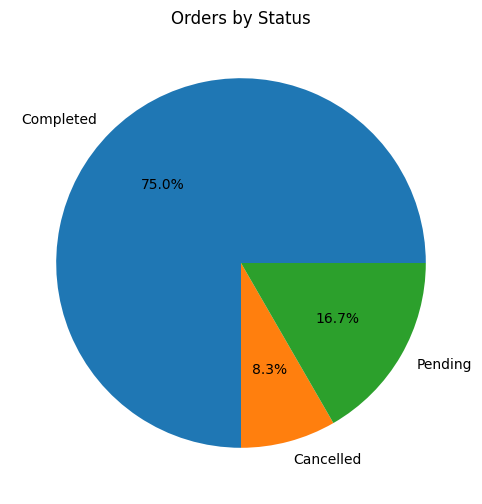

In [4]:
status_df = df.groupBy("status").count()

status_pd = status_df.toPandas()

plt.figure(figsize=(6, 6))
plt.pie(
    status_pd["count"],
    labels=status_pd["status"],
    autopct="%1.1f%%"
)
plt.title("Orders by Status")
plt.show()

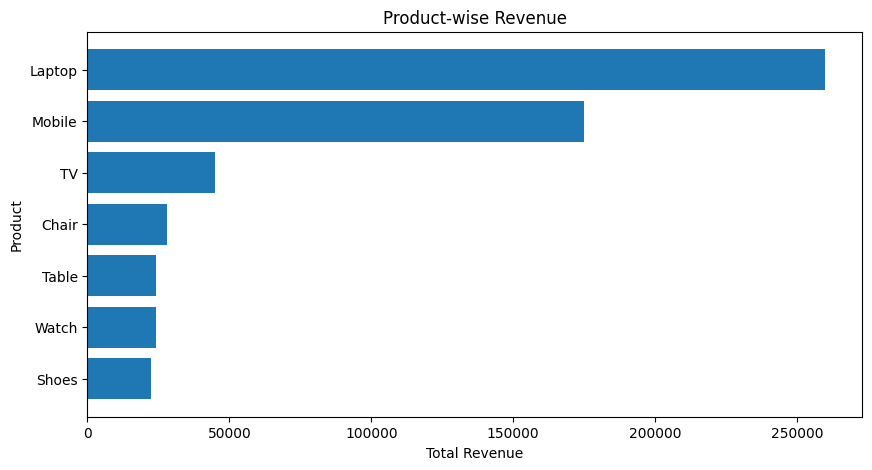

In [5]:
product_revenue_df = df.groupBy("product").agg(
    sum("revenue").alias("total_revenue")
).orderBy(col("total_revenue").desc())

product_pd = product_revenue_df.toPandas()

plt.figure(figsize=(10, 5))
plt.barh(product_pd["product"], product_pd["total_revenue"])
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.title("Product-wise Revenue")
plt.gca().invert_yaxis()
plt.show()

In [8]:
sales_data = [
    (1001, "Hyderabad", "Electronics", "Laptop", 2, 65000, "Completed"),
    (1002, "Bangalore", "Electronics", "Mobile", 3, 25000, "Completed"),
    (1003, "Mumbai", "Furniture", "Chair", 5, 3500, "Pending"),
    (1004, "Delhi", "Furniture", "Table", 2, 12000, "Completed"),
    (1005, "Chennai", "Fashion", "Shoes", 4, 2500, "Completed"),
    (1006, "Pune", "Fashion", "Watch", 1, 8000, "Cancelled"),
    (1007, "Hyderabad", "Electronics", "TV", 1, 45000, "Completed"),
    (1008, "Mumbai", "Electronics", "Laptop", 2, 65000, "Completed"),
    (1009, "Delhi", "Furniture", "Chair", 3, 3500, "Pending"),
    (1010, "Bangalore", "Fashion", "Shoes", 5, 2500, "Completed"),
    (1011, "Chennai", "Electronics", "Mobile", 4, 25000, "Completed"),
    (1012, "Hyderabad", "Fashion", "Watch", 2, 8000, "Completed")
]

columns = [
    "order_id",
    "city",
    "category",
    "product",
    "quantity",
    "price",
    "status"
]

sdf = spark.createDataFrame(sales_data, columns)

display(sdf)

display(sdf.select("category").distinct())


sdf = df.withColumn(
    "revenue",
    col("quantity") * col("price")
)

display(sdf)

city_revenue_df = sdf.groupBy("city").sum("revenue")
city_revenue_df.show()

DataFrame[order_id: bigint, city: string, category: string, product: string, quantity: bigint, price: bigint, status: string]

DataFrame[category: string]

DataFrame[order_id: bigint, city: string, category: string, product: string, quantity: bigint, price: bigint, status: string, revenue: bigint]

+---------+------------+
|     city|sum(revenue)|
+---------+------------+
|Bangalore|       87500|
|  Chennai|      110000|
|   Mumbai|      147500|
|     Pune|        8000|
|    Delhi|       34500|
|Hyderabad|      191000|
+---------+------------+



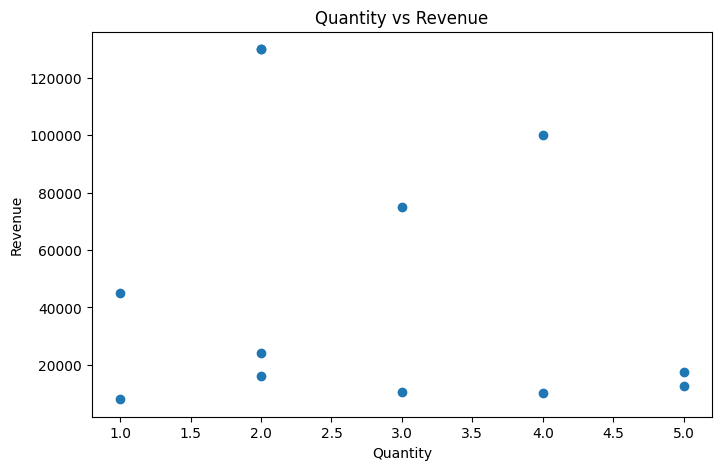

In [9]:
scatter_pd = df.select(
    "quantity",
    "revenue",
    "product"
).toPandas()

plt.figure(figsize=(8, 5))
plt.scatter(scatter_pd["quantity"], scatter_pd["revenue"])
plt.xlabel("Quantity")
plt.ylabel("Revenue")
plt.title("Quantity vs Revenue")
plt.show()

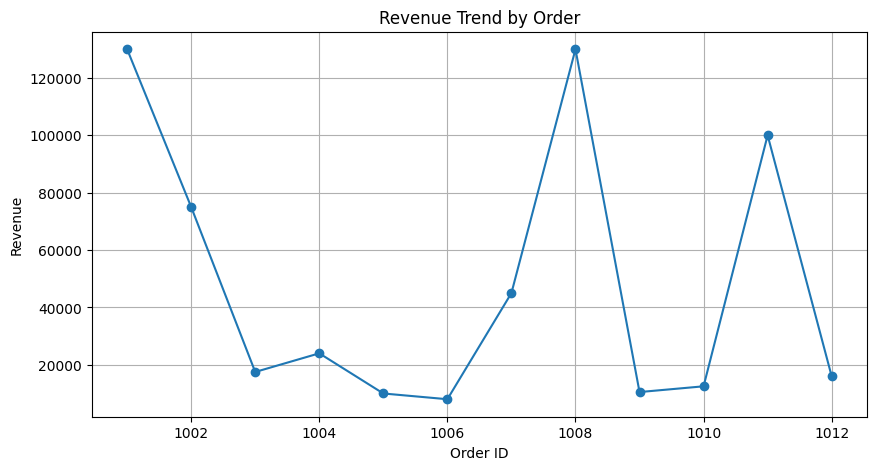

In [10]:
order_pd = df.select(
    "order_id",
    "revenue"
).orderBy("order_id").toPandas()

plt.figure(figsize=(10, 5))
plt.plot(order_pd["order_id"], order_pd["revenue"], marker="o")
plt.xlabel("Order ID")
plt.ylabel("Revenue")
plt.title("Revenue Trend by Order")
plt.grid(True)
plt.show()